# OVERALL PUBLIC OPINION ANALYSIS

Sentiment
Neutral     29772
Positive    17911
Negative     6412
Name: count, dtype: int64


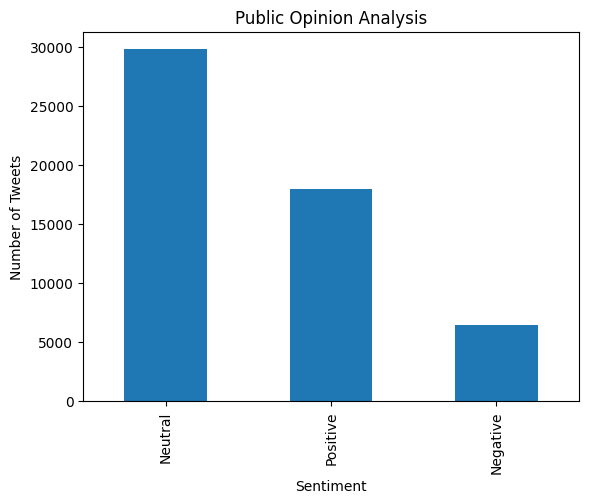

In [ ]:
# Install libraries if needed
# pip install pandas textblob matplotlib

import pandas as pd
from textblob import TextBlob
import matplotlib.pyplot as plt

# 1️⃣ MODIFY: Change the file name to your dataset file
data = pd.read_excel("merged_output.xlsx")

# 2️⃣ MODIFY: Change 'text' if your tweet column has a different name
tweets = data['Text']

sentiments = []

for tweet in tweets:
    analysis = TextBlob(str(tweet))

    if analysis.sentiment.polarity > 0:
        sentiments.append("Positive")
    elif analysis.sentiment.polarity < 0:
        sentiments.append("Negative")
    else:
        sentiments.append("Neutral")

data['Sentiment'] = sentiments

# Count results
result = data['Sentiment'].value_counts()
print(result)

# Plot result
result.plot(kind='bar')
plt.title("Public Opinion Analysis")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.show()

# Public Opinion Analysis For A Specific Topic

Enter topic to analyze: rohit
Tweets found: 17

Public Opinion on: rohit
Positive    11
Neutral      4
Negative     2
Name: count, dtype: int64


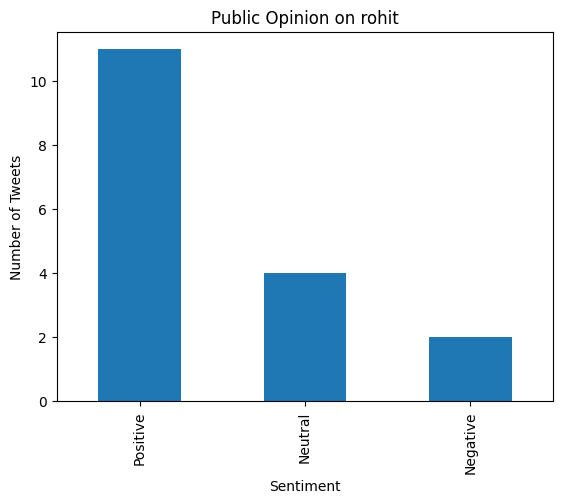

In [ ]:
import pandas as pd
from textblob import TextBlob
import matplotlib.pyplot as plt

data = pd.read_excel("merged_output.xlsx")

tweets = data['Text']

topic = input("Enter topic to analyze: ")

filtered_tweets = tweets[tweets.str.contains(topic, case=False, na=False)]

print("Tweets found:", len(filtered_tweets))

sentiments = []

for tweet in filtered_tweets:
    analysis = TextBlob(str(tweet))

    if analysis.sentiment.polarity > 0:
        sentiments.append("Positive")
    elif analysis.sentiment.polarity < 0:
        sentiments.append("Negative")
    else:
        sentiments.append("Neutral")

result = pd.Series(sentiments).value_counts()

if result.empty:
    print("No tweets found for this topic.")
else:
    print("\nPublic Opinion on:", topic)
    print(result)

    result.plot(kind='bar')
    plt.title("Public Opinion on " + topic)
    plt.xlabel("Sentiment")
    plt.ylabel("Number of Tweets")
    plt.show()

# OVERALL TRANDING TOPIC DECETION

**REMOVE THE STOPWORDS**

In [ ]:
# pip install pandas nltk

import pandas as pd
import nltk
from nltk.corpus import stopwords

# Download stopwords (run once)
nltk.download('stopwords')

# MODIFY 1️⃣: Change dataset file
data = pd.read_excel("merged_output.xlsx")

# MODIFY 2️⃣: Change tweet column name
tweets = data['Text']

stop_words = set(stopwords.words('english'))

clean_words = []

for tweet in tweets:
    words = str(tweet).lower().split()

    for word in words:
        if word not in stop_words:
            clean_words.append(word)

print(clean_words[:50])   # show first few cleaned words

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


['chatgptで遊ぶの忘れてた！！', '書類作るコード書いてみてほしいのと、', 'どこまで思考整理付き合ってくれるのかと、', 'ウミガメのスープやってみたい。', 'あとは調べ物してくれ。', '事務所でちょいといじったが、とりあえず色々やってみたい。', '@alexandrovnaing', 'prohibition', 'chatgpt', 'added', 'honor', 'code', 'daughter’s', 'school', 'schaut', 'euch', 'an,', '@fobizz', '@dianaknodel', 'alles', '⬇️', 'auf', 'die', 'piste', 'bringt,', 'um', 'euch', 'mitzunehmen.', 'morgen', 'startet', '@reg_schulz', '-', 'und', 'di', 'um', '12', 'besprechen', 'wir', '#chatgpt', 'als', 'kritische', 'freundinnen', 'im', 'live-briefing', 'mit', 'spd-vorsitzender', '@eskensaskia', '&amp;', 'diana', 'https://t.co/dsoevjrpbp']


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Top Trending Topics:

chatgpt : 27712
#chatgpt : 9367
de : 7377
ai : 5519
- : 5295
chat : 3855
que : 3294
la : 3062
gpt : 2968
microsoft : 2936


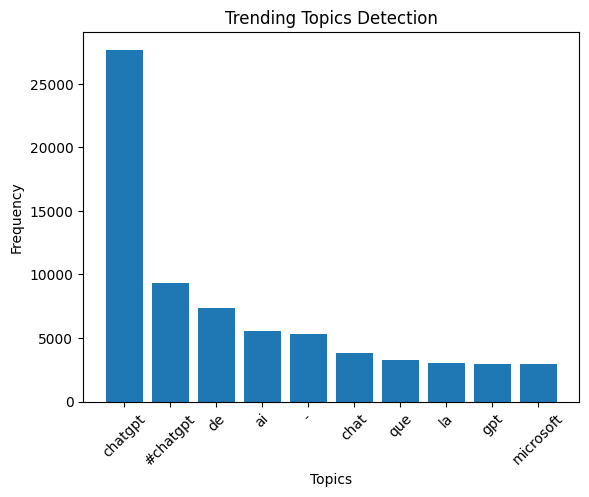

In [ ]:
# pip install pandas nltk matplotlib

import pandas as pd
import nltk
from nltk.corpus import stopwords
from collections import Counter
import matplotlib.pyplot as plt

# Download stopwords (run once)
nltk.download('stopwords')

# MODIFY 1️⃣: Change dataset file name
data = pd.read_excel("merged_output.xlsx")

# MODIFY 2️⃣: Change tweet column name if needed
tweets = data['Text']

stop_words = set(stopwords.words('english'))

clean_words = []

# Cleaning tweets and removing stopwords
for tweet in tweets:
    words = str(tweet).lower().split()

    for word in words:
        if word not in stop_words:
            clean_words.append(word)

# Count word frequency
word_count = Counter(clean_words)

# Top 10 trending topics
trending_topics = word_count.most_common(10)

print("Top Trending Topics:\n")

for word, count in trending_topics:
    print(word, ":", count)

# Plot graph
words = [w[0] for w in trending_topics]
counts = [w[1] for w in trending_topics]

plt.bar(words, counts)
plt.title("Trending Topics Detection")
plt.xlabel("Topics")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

#Overall Most used hashtags

Top Hashtags:
 [('#chatgpt', 9367), ('#ai', 2525), ('#openai', 1010), ('#artificialintelligence', 721), ('#microsoft', 498), ('#chatgpt,', 305), ('#technology', 304), ('#google', 277), ('#ia', 265), ('#machinelearning', 257)]


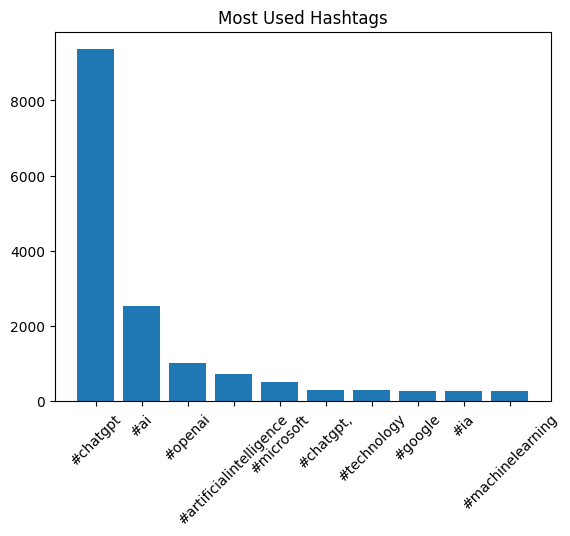

In [ ]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

data = pd.read_excel("merged_output.xlsx")

# MODIFY tweet column
tweets = data['Text']

hashtags = []

for tweet in tweets:
    words = str(tweet).split()

    for word in words:
        if word.startswith("#"):
            hashtags.append(word.lower())

hashtag_count = Counter(hashtags)

top_hashtags = hashtag_count.most_common(10)

print("Top Hashtags:\n", top_hashtags)

labels = [x[0] for x in top_hashtags]
values = [x[1] for x in top_hashtags]

plt.bar(labels, values)
plt.title("Most Used Hashtags")
plt.xticks(rotation=45)
plt.show()

# Trending Hashtags For A Specific Topic

In [ ]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_excel("merged_output.xlsx")

# MODIFY if tweet column name is different
tweets = data['Text']

# User input topic
topic = input("Enter topic: ")

# Filter tweets containing the topic
filtered_tweets = tweets[tweets.str.contains(topic, case=False, na=False)]

print("Tweets found:", len(filtered_tweets))

hashtags = []

# Extract hashtags from filtered tweets
for tweet in filtered_tweets:
    words = str(tweet).split()

    for word in words:
        if word.startswith("#"):
            hashtags.append(word.lower())

# Count hashtag frequency
hashtag_count = Counter(hashtags)

top_hashtags = hashtag_count.most_common(10)

# Check if hashtags exist
if len(top_hashtags) == 0:
    print("No hashtags found for this topic.")
else:
    print("\nTop Hashtags for topic:", topic)
    print(top_hashtags)

    labels = [x[0] for x in top_hashtags]
    values = [x[1] for x in top_hashtags]

    plt.bar(labels, values)
    plt.title("Most Used Hashtags for: " + topic)
    plt.xlabel("Hashtags")
    plt.ylabel("Frequency")
    plt.xticks(rotation=45)
    plt.show()

Enter topic: collage
Tweets found: 1
No hashtags found for this topic.


# Sentiment Analysis For A Specific Topic

Enter topic: movie
Tweets found: 355

Sentiment Analysis for: movie
Positive    224
Neutral      76
Negative     55
Name: count, dtype: int64


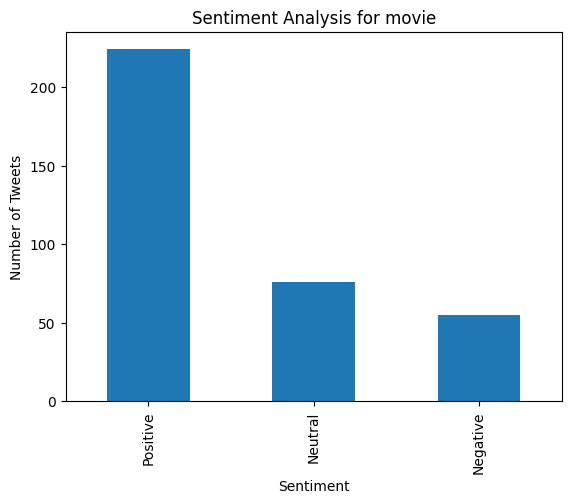

In [ ]:
# pip install pandas textblob matplotlib

import pandas as pd
from textblob import TextBlob
import matplotlib.pyplot as plt

# MODIFY 1️⃣ Change dataset file name
data = pd.read_excel("merged_output.xlsx")

# MODIFY 2️⃣ Change tweet column if different
tweets = data['Text']

# User enters topic
topic = input("Enter topic: ")

# Filter tweets containing that topic
filtered_tweets = tweets[tweets.str.contains(topic, case=False, na=False)]

print("Tweets found:", len(filtered_tweets))

sentiments = []

# Perform sentiment analysis
for tweet in filtered_tweets:
    analysis = TextBlob(str(tweet))

    if analysis.sentiment.polarity > 0:
        sentiments.append("Positive")
    elif analysis.sentiment.polarity < 0:
        sentiments.append("Negative")
    else:
        sentiments.append("Neutral")

# Count sentiment results
result = pd.Series(sentiments).value_counts()

# Check if tweets exist
if result.empty:
    print("No tweets found for this topic.")
else:
    print("\nSentiment Analysis for:", topic)
    print(result)

    # Plot graph
    result.plot(kind='bar')

    plt.title("Sentiment Analysis for " + topic)
    plt.xlabel("Sentiment")
    plt.ylabel("Number of Tweets")

    plt.show()

In [ ]:
data[TIME_COL] = pd.to_datetime(
    data[TIME_COL],
    format='mixed',
    errors='coerce',
    utc=True
)

# remove invalid rows
data = data.dropna(subset=[TIME_COL])

# remove timezone
data[TIME_COL] = data[TIME_COL].dt.tz_convert(None)

# extract hour
data['Hour'] = data[TIME_COL].dt.hour

# 🔥 SAVE permanently
data.to_excel("merged_output.xlsx", index=False)

# Sentiment Analysis Over Time

Enter topic: virat
Tweets found: 64

Sentiment Trend

Sentiment   Negative  Neutral  Positive
Day                                    
2023-01-23       0.0      3.0       0.0
2023-07-21       0.0      1.0       0.0
2023-09-11       0.0      1.0       1.0
2024-08-14       0.0      0.0       1.0
2024-10-13       0.0      0.0       1.0
2024-11-15       0.0      0.0       1.0
2024-11-24       0.0      0.0       2.0
2025-02-23       0.0      1.0       0.0
2025-09-16       1.0      0.0       0.0
2025-11-30       0.0      1.0       0.0
2025-12-03       0.0      0.0       1.0
2025-12-04       0.0      0.0       1.0
2025-12-06       1.0      0.0       0.0
2025-12-24       0.0      1.0       0.0
2025-12-29       0.0      0.0       1.0
2026-01-11       0.0      0.0       1.0
2026-01-18       1.0      0.0       0.0
2026-01-26       0.0      0.0       1.0
2026-01-27       0.0      0.0       1.0
2026-03-03       0.0      0.0       1.0
2026-03-14       0.0      1.0       0.0
2026-03-16       0.0      

<Figure size 1000x600 with 0 Axes>

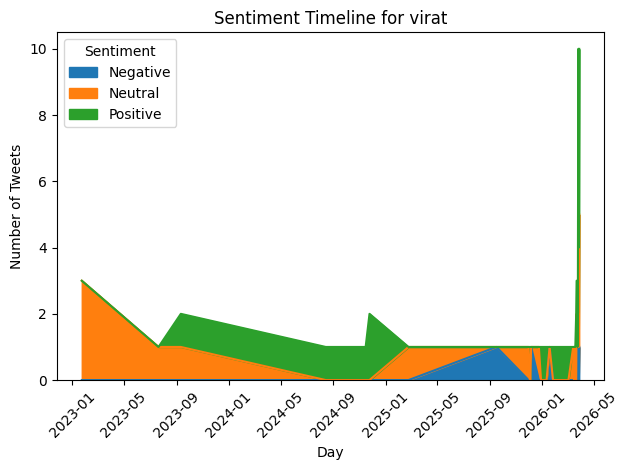

In [ ]:
# pip install pandas textblob matplotlib

import pandas as pd
from textblob import TextBlob
import matplotlib.pyplot as plt

# MODIFY 1️⃣ dataset file
data = pd.read_excel("merged_output.xlsx", engine="openpyxl")

# MODIFY 2️⃣ tweet column
tweets = data['Text']

# MODIFY 3️⃣ datetime column
data['Datetime'] = pd.to_datetime(data['Datetime'])

# Extract day
data['Day'] = data['Datetime'].dt.date

# Topic input
topic = input("Enter topic: ")

# Filter tweets
filtered_data = data[data['Text'].str.contains(topic, case=False, na=False)].copy()

print("Tweets found:", len(filtered_data))

sentiments = []

# Sentiment analysis
for tweet in filtered_data['Text']:

    analysis = TextBlob(str(tweet))

    if analysis.sentiment.polarity > 0:
        sentiments.append("Positive")
    elif analysis.sentiment.polarity < 0:
        sentiments.append("Negative")
    else:
        sentiments.append("Neutral")

filtered_data['Sentiment'] = sentiments

# Group by day
sentiment_day = filtered_data.groupby(['Day','Sentiment']).size().unstack().fillna(0)

print("\nSentiment Trend\n")
print(sentiment_day)

# Better visualization
plt.figure(figsize=(10,6))

sentiment_day.plot(kind="area", stacked=True)

plt.title("Sentiment Timeline for " + topic)
plt.xlabel("Day")
plt.ylabel("Number of Tweets")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

# Best Time For Post For A Topic

Enter topic: virat
Tweets found: 64

Tweets per Hour

Hour
3     4
4     2
7     1
8     3
9     5
10    6
11    5
12    4
13    6
14    3
15    6
16    6
17    6
18    5
20    1
21    1
dtype: int64

Best time to post about virat is around: 10 :00


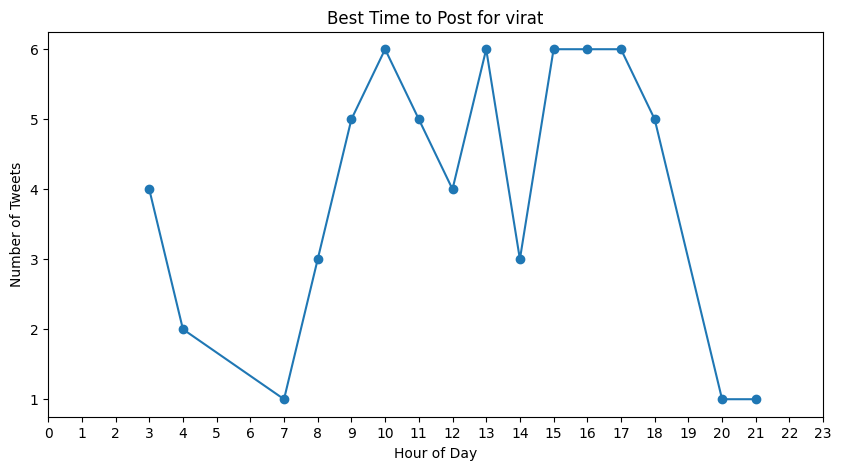

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_excel("merged_output.xlsx", engine="openpyxl")

# convert datetime
data['Datetime'] = pd.to_datetime(data['Datetime'])

# extract hour
data['Hour'] = data['Datetime'].dt.hour

topic = input("Enter topic: ")

# filter tweets for topic
filtered_data = data[data['Text'].str.contains(topic, case=False, na=False)]

print("Tweets found:", len(filtered_data))

# count tweets per hour
hour_count = filtered_data.groupby('Hour').size()

print("\nTweets per Hour\n")
print(hour_count)

# find best hour
best_hour = hour_count.idxmax()

print("\nBest time to post about", topic, "is around:", best_hour, ":00")

# plot graph
plt.figure(figsize=(10,5))

plt.plot(hour_count.index, hour_count.values, marker='o')

plt.title("Best Time to Post for " + topic)
plt.xlabel("Hour of Day")
plt.ylabel("Number of Tweets")

plt.xticks(range(0,24))

plt.show()

In [ ]:
import pandas as pd
data=pd.read_excel("twitter786.xlsx")
data.head()

In [ ]:
# FIXED DATETIME CONVERSION (FINAL)

data[TIME_COL] = pd.to_datetime(
    data[TIME_COL],
    format='mixed',
    errors='coerce',
    utc=True   # 🔥 IMPORTANT FIX
)

# Remove invalid rows
data = data.dropna(subset=[TIME_COL])

# Now safely extract hour
data['Hour'] = data[TIME_COL].dt.hour

# tweet recomendation based on textblob

In [ ]:
# pip install pandas textblob openpyxl

import pandas as pd
from textblob import TextBlob
from collections import Counter
import random
import re

# -----------------------------
# LOAD DATASET
# -----------------------------
file_name = "merged_output.xlsx"   # 👉 change if needed

data = pd.read_excel(file_name, engine="openpyxl")

print("Columns in dataset:", data.columns)

# -----------------------------
# COLUMN NAMES
# -----------------------------
TEXT_COL = "Text"
TIME_COL = "Datetime"

# -----------------------------
# FIX DATETIME (FINAL SOLUTION)
# -----------------------------
data[TIME_COL] = pd.to_datetime(
    data[TIME_COL],
    format='mixed',
    errors='coerce',
    utc=True   # 🔥 fixes timezone issue
)

# remove invalid dates
data = data.dropna(subset=[TIME_COL])

# remove timezone (optional cleaner format)
data[TIME_COL] = data[TIME_COL].dt.tz_convert(None)

# extract hour
data['Hour'] = data[TIME_COL].dt.hour

# -----------------------------
# USER INPUT
# -----------------------------
topic = input("Enter topic: ")

# filter tweets
filtered_data = data[data[TEXT_COL].str.contains(topic, case=False, na=False)].copy()

print("\nTweets found:", len(filtered_data))

# -----------------------------
# TEXT CLEANING
# -----------------------------
def clean_text(text):
    text = str(text)
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    return text.strip()

filtered_data['Clean_Text'] = filtered_data[TEXT_COL].apply(clean_text)

# -----------------------------
# SENTIMENT ANALYSIS
# -----------------------------
positive_texts = []

for tweet in filtered_data['Clean_Text']:
    if TextBlob(tweet).sentiment.polarity > 0:
        positive_texts.append(tweet)

# -----------------------------
# KEYWORD EXTRACTION
# -----------------------------
words = []

for tweet in positive_texts:
    words.extend(tweet.lower().split())

stopwords = ['the','is','and','to','of','in','for','on','with','this','that','it','a']

filtered_words = [w for w in words if w not in stopwords and len(w) > 3]

word_count = Counter(filtered_words)

top_keywords = [x[0] for x in word_count.most_common(5)]

# -----------------------------
# GENERATE TWEET
# -----------------------------
if len(top_keywords) > 0:
    templates = [
        f"{topic.capitalize()} is shaping the future! 🚀",
        f"Exciting times ahead with {topic}! 🔥",
        f"{topic.capitalize()} is changing the world faster than ever.",
        f"The impact of {topic} is incredible!",
    ]

    tweet = random.choice(templates)
    tweet += " " + " ".join(top_keywords[:3])
else:
    tweet = f"{topic.capitalize()} is trending right now!"

# -----------------------------
# HASHTAGS
# -----------------------------
hashtags = []

for t in filtered_data[TEXT_COL]:
    for word in str(t).split():
        if word.startswith("#"):
            hashtags.append(word.lower())

hashtag_count = Counter(hashtags)

top_hashtags = [x[0] for x in hashtag_count.most_common(5)]

if len(top_hashtags) == 0:
    top_hashtags = [f"#{topic.replace(' ','')}", "#trending", "#news"]

# -----------------------------
# BEST TIME TO POST
# -----------------------------
hour_count = filtered_data.groupby('Hour').size()

if len(hour_count) > 0:
    best_hour = hour_count.idxmax()
else:
    best_hour = "No data"

# convert hour to readable format
def format_time(hour):
    if hour == "No data":
        return hour
    suffix = "AM" if hour < 12 else "PM"
    hour = hour if hour <= 12 else hour - 12
    return f"{hour}:00 {suffix}"

# -----------------------------
# FINAL OUTPUT
# -----------------------------
print("\n📌 Recommended Tweet:\n")
print(tweet)

print("\n🔥 Suggested Hashtags:\n")
print(top_hashtags)

print("\n⏰ Best Time to Post:\n")
print(format_time(best_hour))

Columns in dataset: Index(['Datetime', 'Tweet Id', 'Text', 'Username', 'Permalink', 'User',
       'Outlinks', 'CountLinks', 'ReplyCount', 'RetweetCount', 'LikeCount',
       'QuoteCount', 'ConversationId', 'Language', 'Source', 'Media',
       'QuotedTweet', 'MentionedUsers', 'hashtag', 'hastag_counts'],
      dtype='object')
Enter topic: virat kohli

Tweets found: 49

📌 Recommended Tweet:

Virat kohli is changing the world faster than ever. virat kohli most

🔥 Suggested Hashtags:

['#tataipl', '#rcbvsrh', '#ipl2026', '#captainsday', '#playbold']

⏰ Best Time to Post:

1:00 PM


# tweet recomentadion based on tf-idf

In [ ]:
# pip install pandas scikit-learn openpyxl

import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# -----------------------------
# LOAD DATA
# -----------------------------
data = pd.read_excel("twitter786_cleaned.xlsx")

TEXT_COL = "Text"

# remove nulls
data = data.dropna(subset=[TEXT_COL])

# -----------------------------
# USER INPUT
# -----------------------------
topic = input("Enter topic: ")

# -----------------------------
# TF-IDF VECTORIZATION
# -----------------------------
vectorizer = TfidfVectorizer(stop_words='english')

tfidf_matrix = vectorizer.fit_transform(data[TEXT_COL])

# convert topic to vector
topic_vector = vectorizer.transform([topic])

# -----------------------------
# SIMILARITY CALCULATION
# -----------------------------
similarity_scores = cosine_similarity(topic_vector, tfidf_matrix)

# get top 5 similar tweets
top_indices = similarity_scores[0].argsort()[-5:][::-1]

recommended_tweets = data.iloc[top_indices][TEXT_COL]

# -----------------------------
# OUTPUT
# -----------------------------
print("\n📌 Recommended Tweets:\n")

for i, tweet in enumerate(recommended_tweets, 1):
    print(f"{i}. {tweet}\n")

Enter topic: virat kohli

📌 Recommended Tweets:

1. VIRAT KOHLI IS RIPPED. 🥶

- The fitness level of King Kohli is Insane! https://t.co/eMdwvLxhD0

2. As if he never left. Watch Virat Kohli in the nets on our app 🍿

3. VIRAT KOHLI AT THE EMPTY ELEVATOR OF RCB. ♥️👌

- King Kohli, Absolute Character! 

https://t.co/k5cDyG6STI

4. The impact of Virat Kohli’s one Instagram story. 😂 https://t.co/vGTTIsk6B8

5. 🚨 KING KOHLI AT THE TOP 🚨

- Virat Kohli is the highest earning Cricketer in the World in 2025. (ABP News). https://t.co/C1NrlCmKnw



# tweet recomendation on tf-idf, and filter by sentiment, hashtasgs, best-time

In [ ]:
# pip install pandas nltk openpyxl

import pandas as pd
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

# download vader (run once)
nltk.download('vader_lexicon')

# load data
data = pd.read_excel("twitter786_cleaned.xlsx")

TEXT_COL = "Text"

# initialize vader
sia = SentimentIntensityAnalyzer()

# function to label sentiment
def get_sentiment(text):
    score = sia.polarity_scores(str(text))['compound']

    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

# create Actual_Sentiment column
data['Actual_Sentiment'] = data[TEXT_COL].apply(get_sentiment)

# save new dataset
data.to_excel("twitter_with_actual_sentiment.xlsx", index=False)

print("✅ 'Actual_Sentiment' column created successfully!")

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


✅ 'Actual_Sentiment' column created successfully!


In [ ]:
# pip install pandas scikit-learn textblob openpyxl

import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from textblob import TextBlob
from collections import Counter

# -----------------------------
# LOAD DATA
# -----------------------------
data = pd.read_excel("twitter786_cleaned.xlsx")

TEXT_COL = "Text"
TIME_COL = "Datetime"

# remove nulls
data = data.dropna(subset=[TEXT_COL, TIME_COL])

# convert datetime (safe)
data[TIME_COL] = pd.to_datetime(data[TIME_COL], errors='coerce')
data = data.dropna(subset=[TIME_COL])

# extract hour
data['Hour'] = data[TIME_COL].dt.hour

# -----------------------------
# USER INPUT
# -----------------------------
topic = input("Enter topic: ")
user_sentiment = input("Enter sentiment (positive/negative/neutral): ").capitalize()

# -----------------------------
# SENTIMENT ANALYSIS
# -----------------------------
def get_sentiment(text):
    polarity = TextBlob(str(text)).sentiment.polarity
    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

data['Sentiment'] = data[TEXT_COL].apply(get_sentiment)

# filter by sentiment
filtered_data = data[data['Sentiment'] == user_sentiment]

# fallback if empty
if len(filtered_data) == 0:
    print("\n⚠️ No tweets found for this sentiment, using all tweets...")
    filtered_data = data.copy()

print("Tweets after sentiment filter:", len(filtered_data))

# -----------------------------
# ML: TF-IDF + SIMILARITY
# -----------------------------
vectorizer = TfidfVectorizer(stop_words='english')

tfidf_matrix = vectorizer.fit_transform(filtered_data[TEXT_COL])

topic_vector = vectorizer.transform([topic])

similarity_scores = cosine_similarity(topic_vector, tfidf_matrix)

# top 5 tweets
top_indices = similarity_scores[0].argsort()[-5:][::-1]

recommended = filtered_data.iloc[top_indices]

# -----------------------------
# HASHTAGS
# -----------------------------
hashtags = []

for tweet in recommended[TEXT_COL]:
    for word in str(tweet).split():
        if word.startswith("#"):
            hashtags.append(word.lower())

hashtag_count = Counter(hashtags)
top_hashtags = [x[0] for x in hashtag_count.most_common(5)]

# fallback hashtags
if len(top_hashtags) == 0:
    top_hashtags = [f"#{topic.replace(' ','')}", "#trending", "#news"]

# -----------------------------
# BEST TIME TO POST
# -----------------------------
hour_count = filtered_data.groupby('Hour').size()

if len(hour_count) > 0:
    best_hour = hour_count.idxmax()
else:
    best_hour = None

def format_time(hour):
    if hour is None:
        return "No data"
    suffix = "AM" if hour < 12 else "PM"
    hour = hour if hour <= 12 else hour - 12
    return f"{hour}:00 {suffix}"

# -----------------------------
# OUTPUT
# -----------------------------
print("\n📌 Recommended Tweets:\n")

for i, tweet in enumerate(recommended[TEXT_COL], 1):
    print(f"{i}. {tweet}\n")

print("🔥 Suggested Hashtags:")
print(top_hashtags)

print("\n⏰ Best Time to Post:")
print(format_time(best_hour))

Enter topic: ipl
Enter sentiment (positive/negative/neutral): negative
Tweets after sentiment filter: 6412

📌 Recommended Tweets:

1. PSL had the contracts. IPL made one call.

9 players. 9 different franchises. Same decision.

Fraser-McGurk, Muzarabani, Gurbaz, Johnson, Mills. The moment an IPL spot opened up, the PSL contract meant nothing.

It's just the reality of world cricket in 2026. 
This is the reality check for PSL. 

Every league on the planet is essentially a waiting room for the IPL. Players show up, do their bit, and the moment that Mumbai or Bangalore call comes, bags are packed.

The money is bigger. The exposure is bigger. The competition is bigger.

It stopped being a debate a long time ago.

2. 🚨 BAD NEWS FOR RCB FANS 🚨

Bengaluru Police said 🗣️: – 

- No physical tickets allowed for IPL 2026 

- Only digital QR codes will work to stop last year's deadly crowd accident

- We will not allow any crowding outside the venue. 

#IPL2026 | #RCBvsSRH

3. 🚨 BAD NEWS FOR RCB 

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd

# -----------------------------
# LOAD DATA
# -----------------------------
data = pd.read_excel("twitter_with_actual_sentiment.xlsx")

TEXT_COL = "Text"
LABEL_COL = "Actual_Sentiment"

# remove nulls
data = data.dropna(subset=[TEXT_COL, LABEL_COL])

# -----------------------------
# PREPARE DATA
# -----------------------------
X = data[TEXT_COL]
y = data[LABEL_COL]

# vectorization
vectorizer = TfidfVectorizer(stop_words='english')
X_vec = vectorizer.fit_transform(X)

# train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_vec, y, test_size=0.2, random_state=42
)

# -----------------------------
# TRAIN MODEL
# -----------------------------
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

# -----------------------------
# PREDICT
# -----------------------------
y_pred = model.predict(X_test)

# -----------------------------
# ACCURACY
# -----------------------------
accuracy = accuracy_score(y_test, y_pred)

print("\n✅ Model Accuracy:", accuracy)

# -----------------------------
# DETAILED REPORT
# -----------------------------
print("\n📊 Classification Report:\n")
print(classification_report(y_test, y_pred))

# -----------------------------
# CONFUSION MATRIX
# -----------------------------
print("\n📌 Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))


✅ Model Accuracy: 0.8185599408448101

📊 Classification Report:

              precision    recall  f1-score   support

    Negative       0.83      0.43      0.57      1698
     Neutral       0.81      0.95      0.87      5439
    Positive       0.83      0.80      0.82      3682

    accuracy                           0.82     10819
   macro avg       0.82      0.73      0.75     10819
weighted avg       0.82      0.82      0.81     10819


📌 Confusion Matrix:

[[ 735  593  370]
 [  50 5172  217]
 [  98  635 2949]]


In [ ]:
data.head()

,Datetime,Tweet Id,Text,Username,Permalink,User,Outlinks,CountLinks,ReplyCount,RetweetCount,...,ConversationId,Language,Source,Media,QuotedTweet,MentionedUsers,hashtag,hastag_counts,Hour,Actual_Sentiment
0,2023-01-22 13:44:34,1617156270871698944,ChatGPTで遊ぶの忘れてた！！\n書類作るコード書いてみてほしいのと、\nどこまで思考整...,mochico0123,https://twitter.com/mochico0123/status/1617156...,https://twitter.com/mochico0123,NaN,NaN,1,0,...,1.617156e+18,ja,"<a href=""http://twitter.com/download/iphone"" r...",NaN,NaN,NaN,[],0.0,13,Neutral
1,2023-01-22 13:44:39,1617156291046134016,@AlexandrovnaIng Prohibition of ChatGPT has be...,Caput_LupinumSG,https://twitter.com/Caput_LupinumSG/status/161...,https://twitter.com/Caput_LupinumSG,NaN,NaN,1,0,...,1.617149e+18,en,"<a href=""http://twitter.com/download/iphone"" r...",NaN,NaN,"[User(username='AlexandrovnaIng', id=282705900...",[],0.0,13,Positive
2,2023-01-22 13:44:44,1617156308926349056,"Schaut Euch an, was @fobizz @DianaKnodel alles...",ciffi,https://twitter.com/ciffi/status/1617156308926...,https://twitter.com/ciffi,['https://us02web.zoom.us/webinar/register/801...,"['https://t.co/DsoeVJrPBp', 'https://t.co/HflT...",0,0,...,1.617156e+18,de,"<a href=""http://twitter.com/#!/download/ipad"" ...",[Photo(previewUrl='https://pbs.twimg.com/media...,https://twitter.com/DianaKnodel/status/1617153...,"[User(username='fobizz', id=884708145792253952...",['#ChatGPT'],1.0,13,Negative
3,2023-01-22 13:44:49,1617156332297256960,Bow down to chatGPT 🫡..... https://t.co/ENTSzi...,Vishwasrisiri,https://twitter.com/Vishwasrisiri/status/16171...,https://twitter.com/Vishwasrisiri,['https://twitter.com/agadmator/status/1617155...,['https://t.co/ENTSzi2AQ9'],0,0,...,1.617156e+18,en,"<a href=""http://twitter.com/download/android"" ...",NaN,https://twitter.com/agadmator/status/161715501...,NaN,[],0.0,13,Neutral
4,2023-01-22 13:44:52,1617156345064570880,"Profilinde vatan, Türkiye falan yazan bireyler...",0xGenetikciniz,https://twitter.com/0xGenetikciniz/status/1617...,https://twitter.com/0xGenetikciniz,NaN,NaN,0,0,...,1.617156e+18,tr,"<a href=""http://twitter.com/download/iphone"" r...",NaN,NaN,NaN,[],0.0,13,Neutral
